# Visualización de Resultados del Test de Estrés

Este notebook permite analizar los resultados del test de estrés del SmartNeo4jEngine.

## Contenido
1. Carga y análisis de resultados generales
2. Análisis por nivel de dificultad
3. Análisis por categoría de consulta
4. Análisis de fallos y limitaciones
5. Comparación con test básico
6. Consultas más difíciles y exitosas

In [19]:
# Importar librerías necesarias
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Configurar estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

## 1. Carga de Resultados del Test de Estrés

In [20]:
# Cargar resultados del test de estrés
with open('stress_test_results_flash.json', 'r', encoding='utf-8') as f:
    stress_results = json.load(f)

# Cargar también resultados del test básico para comparar
with open('evaluation_results_flash.json', 'r', encoding='utf-8') as f:
    basic_results = json.load(f)

# Mostrar metadata
print("="*80)
print("🔥 TEST DE ESTRÉS - METADATOS")
print("="*80)
print(f"Fecha: {stress_results['metadata']['timestamp']}")
print(f"Tipo de test: {stress_results['metadata']['test_type']}")
print(f"Modelo LLM: {stress_results['metadata']['model']}")
print()

🔥 TEST DE ESTRÉS - METADATOS
Fecha: 2025-11-27T22:54:15.676376
Tipo de test: stress_test
Modelo LLM: models/gemini-2.5-flash



## 2. Resumen General

In [21]:
# Resumen general
summary = stress_results['summary']

print("="*80)
print("🎯 RESUMEN DEL TEST DE ESTRÉS")
print("="*80)
print(f"Total de pruebas:                {summary['total_tests']}")
print(f"Pruebas exitosas:                {summary['successful']} ✅")
print(f"Pruebas fallidas:                {summary['failed']} ❌")
print(f"Tasa de éxito:                   {summary['success_rate']*100:.1f}%")
print(f"Tiempo promedio de ejecución:    {summary['avg_execution_time']:.3f}s")
print()

# Comparación con test básico
basic_summary = basic_results['summary']
print("="*80)
print("📊 COMPARACIÓN: TEST BÁSICO vs TEST DE ESTRÉS")
print("="*80)
print(f"{'Métrica':<40} {'Test Básico':<20} {'Test de Estrés':<20}")
print("-"*80)
print(f"{'Tasa de éxito':<40} {basic_summary['success_rate']*100:<20.1f}% {summary['success_rate']*100:<20.1f}%")
print(f"{'Tiempo promedio':<40} {basic_summary['avg_execution_time']:<20.2f}s {summary['avg_execution_time']:<20.2f}s")
print(f"{'Total de pruebas':<40} {basic_summary['total_tests']:<20} {summary['total_tests']:<20}")

🎯 RESUMEN DEL TEST DE ESTRÉS
Total de pruebas:                20
Pruebas exitosas:                16 ✅
Pruebas fallidas:                4 ❌
Tasa de éxito:                   80.0%
Tiempo promedio de ejecución:    19.344s

📊 COMPARACIÓN: TEST BÁSICO vs TEST DE ESTRÉS
Métrica                                  Test Básico          Test de Estrés      
--------------------------------------------------------------------------------
Tasa de éxito                            84.6                % 80.0                %
Tiempo promedio                          3.60                s 19.34               s
Total de pruebas                         13                   20                  


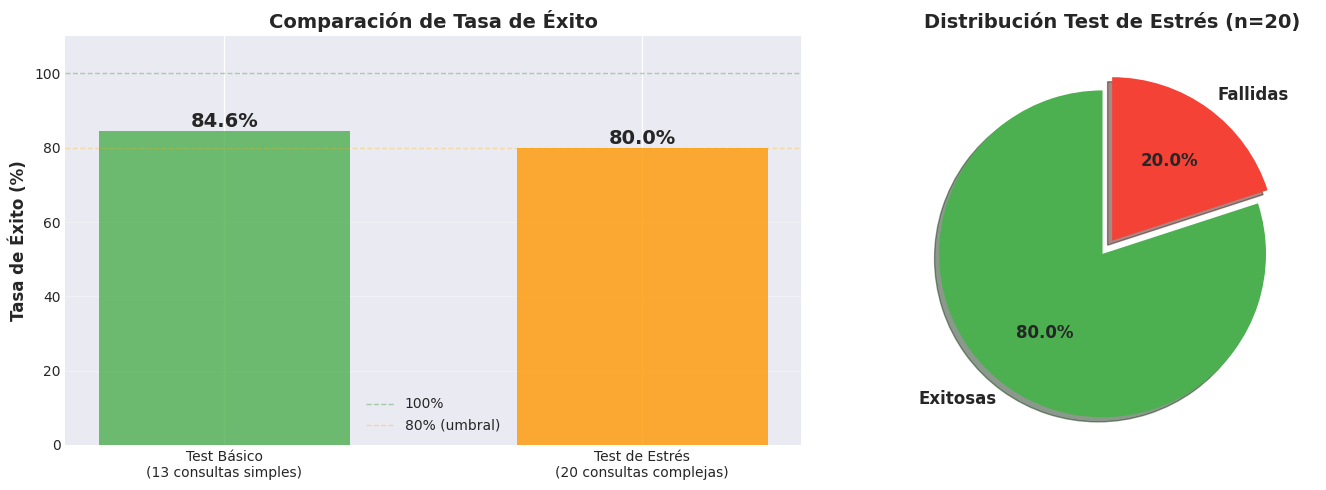

In [22]:
# Gráfico comparativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Comparación de tasa de éxito
tests = ['Test Básico\n(13 consultas simples)', 'Test de Estrés\n(20 consultas complejas)']
success_rates = [basic_summary['success_rate']*100, summary['success_rate']*100]
colors = ['#4CAF50', '#FF9800']

bars = ax1.bar(tests, success_rates, color=colors, alpha=0.8, width=0.6)
ax1.set_ylabel('Tasa de Éxito (%)', fontsize=12, fontweight='bold')
ax1.set_title('Comparación de Tasa de Éxito', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 110])
ax1.axhline(y=100, color='green', linestyle='--', linewidth=1, alpha=0.3, label='100%')
ax1.axhline(y=80, color='orange', linestyle='--', linewidth=1, alpha=0.3, label='80% (umbral)')
ax1.grid(axis='y', alpha=0.3)
ax1.legend()

for bar, rate in zip(bars, success_rates):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{rate:.1f}%',
            ha='center', va='bottom', fontsize=14, fontweight='bold')

# Subplot 2: Distribución de éxito/fallo
labels = ['Exitosas', 'Fallidas']
sizes = [summary['successful'], summary['failed']]
colors_pie = ['#4CAF50', '#F44336']
explode = (0.1, 0)

ax2.pie(sizes, explode=explode, labels=labels, colors=colors_pie,
       autopct='%1.1f%%', shadow=True, startangle=90,
       textprops={'fontsize': 12, 'weight': 'bold'})
ax2.set_title(f'Distribución Test de Estrés (n={summary["total_tests"]})',
            fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Análisis por Nivel de Dificultad

In [23]:
# Análisis por dificultad
by_difficulty = stress_results['by_difficulty']

print("="*80)
print("🔥 RESULTADOS POR NIVEL DE DIFICULTAD")
print("="*80)

for diff, metrics in by_difficulty.items():
    print(f"\n{diff.upper()}")
    print(f"  Total de pruebas:     {metrics['total']}")
    print(f"  Pruebas exitosas:     {metrics['success']}/{metrics['total']} ({metrics['success_rate']*100:.1f}%)")
    print(f"  Tiempo promedio:      {metrics['avg_time']:.3f}s")

🔥 RESULTADOS POR NIVEL DE DIFICULTAD

HARD
  Total de pruebas:     7
  Pruebas exitosas:     6/7 (85.7%)
  Tiempo promedio:      20.372s

VERY_HARD
  Total de pruebas:     8
  Pruebas exitosas:     5/8 (62.5%)
  Tiempo promedio:      18.106s

EXTREME
  Total de pruebas:     3
  Pruebas exitosas:     2/3 (66.7%)
  Tiempo promedio:      19.884s


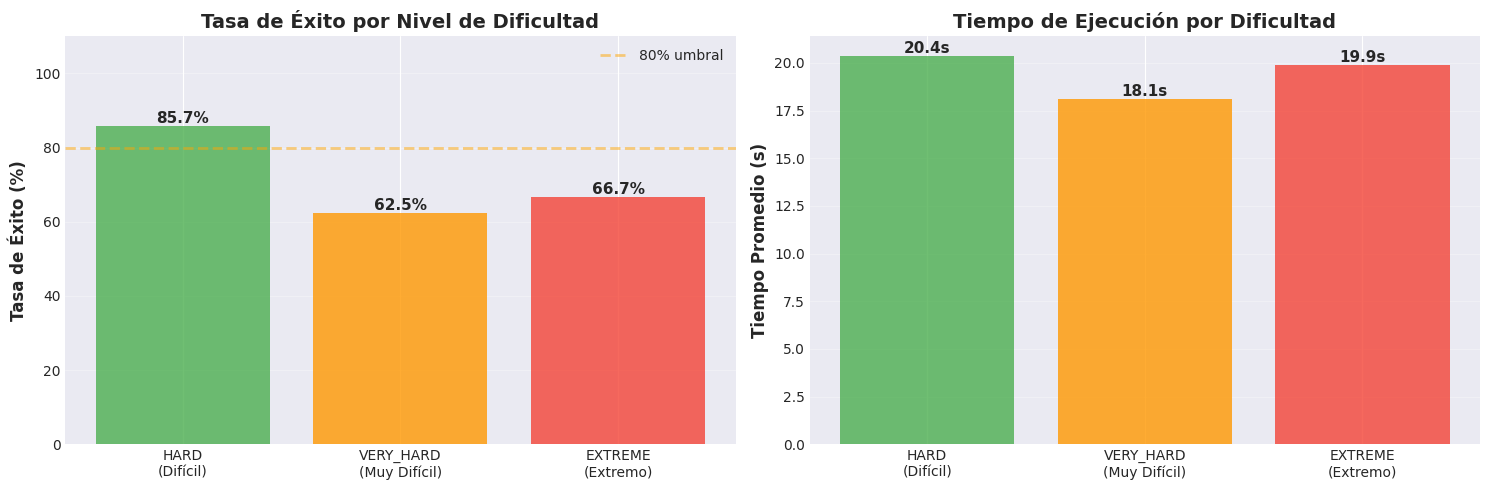

In [24]:
# Gráfico de tasa de éxito por dificultad
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Preparar datos
difficulty_order = ['hard', 'very_hard', 'extreme']
diff_labels = ['HARD\n(Difícil)', 'VERY_HARD\n(Muy Difícil)', 'EXTREME\n(Extremo)']
success_rates_diff = [by_difficulty[d]['success_rate']*100 for d in difficulty_order]
avg_times_diff = [by_difficulty[d]['avg_time'] for d in difficulty_order]
colors_diff = ['#4CAF50', '#FF9800', '#F44336']

# Subplot 1: Tasa de éxito por dificultad
bars1 = ax1.bar(diff_labels, success_rates_diff, color=colors_diff, alpha=0.8)
ax1.set_ylabel('Tasa de Éxito (%)', fontsize=12, fontweight='bold')
ax1.set_title('Tasa de Éxito por Nivel de Dificultad', fontsize=14, fontweight='bold')
ax1.set_ylim([0, 110])
ax1.axhline(y=80, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='80% umbral')
ax1.grid(axis='y', alpha=0.3)
ax1.legend()

for bar, rate in zip(bars1, success_rates_diff):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{rate:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Subplot 2: Tiempo promedio por dificultad
bars2 = ax2.bar(diff_labels, avg_times_diff, color=colors_diff, alpha=0.8)
ax2.set_ylabel('Tiempo Promedio (s)', fontsize=12, fontweight='bold')
ax2.set_title('Tiempo de Ejecución por Dificultad', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

for bar, time in zip(bars2, avg_times_diff):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{time:.1f}s',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Análisis por Categoría de Consulta

In [25]:
# Análisis por categoría
by_category = stress_results['by_category']

print("="*80)
print("📂 RESULTADOS POR CATEGORÍA DE CONSULTA")
print("="*80)

for cat, metrics in sorted(by_category.items(), key=lambda x: x[1]['success_rate'], reverse=True):
    print(f"\n{cat.upper().replace('_', ' ')}")
    print(f"  Total: {metrics['total']}")
    print(f"  Éxito: {metrics['success']}/{metrics['total']} ({metrics['success_rate']*100:.1f}%)")
    print(f"  Tiempo promedio: {metrics['avg_time']:.3f}s")

📂 RESULTADOS POR CATEGORÍA DE CONSULTA

ANALISIS RUTAS
  Total: 3
  Éxito: 3/3 (100.0%)
  Tiempo promedio: 8.956s

FUNNEL CONVERSION
  Total: 2
  Éxito: 2/2 (100.0%)
  Tiempo promedio: 37.471s

NEGACION
  Total: 2
  Éxito: 2/2 (100.0%)
  Tiempo promedio: 6.271s

MULTI CONCEPTO
  Total: 2
  Éxito: 2/2 (100.0%)
  Tiempo promedio: 11.290s

AMBIGUEDAD
  Total: 3
  Éxito: 2/3 (66.7%)
  Tiempo promedio: 19.330s

TEMPORAL COMPLEJO
  Total: 2
  Éxito: 1/2 (50.0%)
  Tiempo promedio: 14.097s

SEGMENTACION
  Total: 2
  Éxito: 1/2 (50.0%)
  Tiempo promedio: 39.701s

AGREGACION MULTINIVEL
  Total: 3
  Éxito: 1/3 (33.3%)
  Tiempo promedio: 23.419s


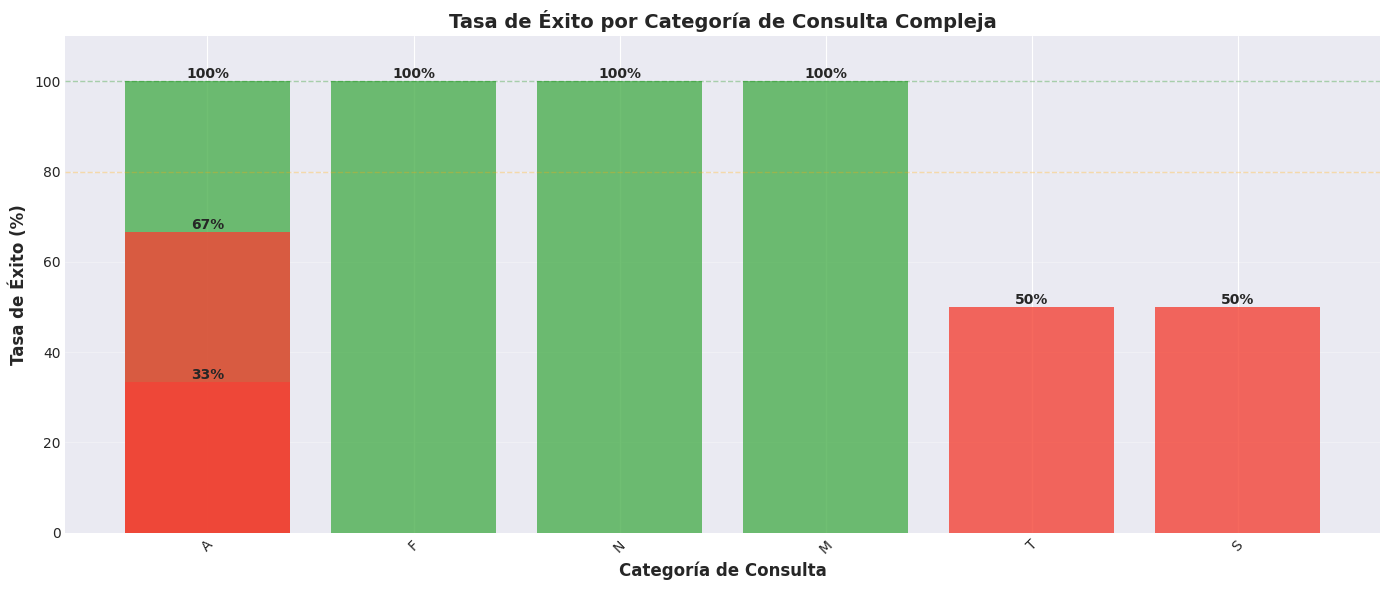

In [26]:
# Gráfico de categorías
fig, ax = plt.subplots(figsize=(14, 6))

# Preparar datos ordenados por tasa de éxito
sorted_cats = sorted(by_category.items(), key=lambda x: x[1]['success_rate'], reverse=True)
cat_names = [c[0].replace('_', '\n').upper() for c, _ in sorted_cats]
success_rates_cat = [m['success_rate']*100 for _, m in sorted_cats]

# Colores según tasa de éxito
colors_cat = ['#4CAF50' if rate == 100 else '#FF9800' if rate >= 80 else '#F44336' 
              for rate in success_rates_cat]

bars = ax.bar(cat_names, success_rates_cat, color=colors_cat, alpha=0.8)
ax.set_ylabel('Tasa de Éxito (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Categoría de Consulta', fontsize=12, fontweight='bold')
ax.set_title('Tasa de Éxito por Categoría de Consulta Compleja', fontsize=14, fontweight='bold')
ax.set_ylim([0, 110])
ax.axhline(y=100, color='green', linestyle='--', linewidth=1, alpha=0.3)
ax.axhline(y=80, color='orange', linestyle='--', linewidth=1, alpha=0.3)
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)

for bar, rate in zip(bars, success_rates_cat):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{rate:.0f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Análisis Detallado de Tests Individuales

In [27]:
# Crear DataFrame con resultados individuales
test_results = stress_results['test_results']
df = pd.DataFrame(test_results)

# Mostrar tabla completa
display_df = df[['test_id', 'category', 'difficulty', 'question', 'success', 'execution_time']]
display_df = display_df.rename(columns={
    'test_id': 'ID',
    'category': 'Categoría',
    'difficulty': 'Dificultad',
    'question': 'Pregunta',
    'success': 'Éxito',
    'execution_time': 'Tiempo (s)'
})

print("="*80)
print("📋 RESULTADOS INDIVIDUALES DEL TEST DE ESTRÉS")
print("="*80)
display_df

📋 RESULTADOS INDIVIDUALES DEL TEST DE ESTRÉS


,ID,Categoría,Dificultad,Pregunta,Éxito,Tiempo (s)
0,stress_agg_01,agregacion_multinivel,hard,¿Cuál es el promedio de eventos por sesión par...,False,40.227669
1,stress_agg_02,agregacion_multinivel,very_hard,De los visitantes que se convirtieron en usuar...,False,8.670171
2,stress_agg_03,agregacion_multinivel,extreme,¿Cuál es la tasa de conversión por cohorte men...,True,21.360517
3,stress_path_01,analisis_rutas,hard,¿Cuántos pasos promedio hay entre la primera s...,True,15.276876
4,stress_path_02,analisis_rutas,very_hard,"¿Qué secuencia de tipos de eventos (page_view,...",True,5.395437
5,stress_path_03,analisis_rutas,extreme,Identifica usuarios que visitaron desde mobile...,True,6.194723
6,stress_funnel_01,funnel_conversion,hard,¿Cuál es la tasa de abandono en cada paso del ...,True,35.846115
7,stress_funnel_02,funnel_conversion,very_hard,¿En qué punto del customer journey (número de ...,True,39.096413
8,stress_temporal_01,temporal_complejo,hard,¿Cuál es la diferencia en días promedio entre ...,True,11.183363
9,stress_temporal_02,temporal_complejo,very_hard,¿Qué día de la semana tiene la mayor tasa de c...,False,4.919873


## 6. Análisis de Fallos y Limitaciones

In [28]:
# Analizar tests fallidos
df_failed = df[df['success'] == False]

print("="*80)
print("❌ ANÁLISIS DE TESTS FALLIDOS")
print("="*80)

if len(df_failed) > 0:
    print(f"\nTotal de tests fallidos: {len(df_failed)}")
    print("\nDetalle de fallos:\n")
    
    for idx, row in df_failed.iterrows():
        print(f"[{row['test_id']}] - {row['difficulty'].upper()}")
        print(f"  Categoría: {row['category']}")
        print(f"  Pregunta: {row['question']}")
        print(f"  Desafío: {row['notes']}")
        print(f"  Error: {row.get('error', 'N/A')[:150]}")
        print(f"  Resultado: {row['result_sample'][:150]}")
        print()
else:
    print("\n✅ No hubo tests fallidos")

❌ ANÁLISIS DE TESTS FALLIDOS

Total de tests fallidos: 5

Detalle de fallos:

[stress_agg_01] - HARD
  Categoría: agregacion_multinivel
  Pregunta: ¿Cuál es el promedio de eventos por sesión para usuarios que han realizado al menos una conversión, agrupado por ciudad y dispositivo?
  Desafío: Requiere múltiples niveles de agregación y filtrado
  Error: 
  Resultado: Error procesando solicitud: No se pudo generar Cypher válido tras 3 intentos.

[stress_agg_02] - VERY_HARD
  Categoría: agregacion_multinivel
  Pregunta: De los visitantes que se convirtieron en usuarios, ¿cuántas sesiones promedio tuvieron antes y después de su identificación?
  Desafío: Requiere partición temporal basada en evento de identificación
  Error: 
  Resultado: [{'averageSessionsBeforeIdentification': 0.5, 'averageSessionsAfterIdentification': 106.5}]

[stress_temporal_02] - VERY_HARD
  Categoría: temporal_complejo
  Pregunta: ¿Qué día de la semana tiene la mayor tasa de conversión, considerando solo sesiones qu

In [29]:
# Análisis de tests exitosos más desafiantes
df_success = df[df['success'] == True]
df_extreme_success = df_success[df_success['difficulty'] == 'extreme']

print("="*80)
print("⭐ TESTS EXTREMOS EXITOSOS")
print("="*80)

if len(df_extreme_success) > 0:
    print(f"\nTests de dificultad EXTREMA que fueron exitosos: {len(df_extreme_success)}")
    print("\nDetalle:\n")
    
    for idx, row in df_extreme_success.iterrows():
        print(f"[{row['test_id']}] - {row['category'].upper()}")
        print(f"  Pregunta: {row['question']}")
        print(f"  Desafío: {row['notes']}")
        print(f"  Tiempo: {row['execution_time']:.2f}s")
        print(f"  Resultado: {row['result_sample'][:150]}...")
        print()
else:
    print("\n⚠️ No hubo tests extremos exitosos")

⭐ TESTS EXTREMOS EXITOSOS

Tests de dificultad EXTREMA que fueron exitosos: 4

Detalle:

[stress_agg_03] - AGREGACION_MULTINIVEL
  Pregunta: ¿Cuál es la tasa de conversión por cohorte mensual de registro, considerando solo conversiones que ocurrieron dentro de los primeros 30 días?
  Desafío: Requiere análisis de cohortes con ventanas temporales
  Tiempo: 21.36s
  Resultado: [{'registration_month': '2024-12', 'total_users_in_cohort': 11, 'users_with_conversion_within_30_days': 8, 'conversion_rate_percentage': 72.7272727272...

[stress_path_03] - ANALISIS_RUTAS
  Pregunta: Identifica usuarios que visitaron desde mobile, luego desktop, y finalmente convirtieron desde mobile nuevamente
  Desafío: Requiere pattern matching de secuencias específicas
  Tiempo: 6.19s
  Resultado: []...

[stress_temporal_03] - TEMPORAL_COMPLEJO
  Pregunta: Identifica usuarios con comportamiento estacional: que tienen picos de actividad cada 7 días aproximadamente
  Desafío: Requiere análisis de periodicidad
  

## 7. Análisis de Tiempos de Ejecución

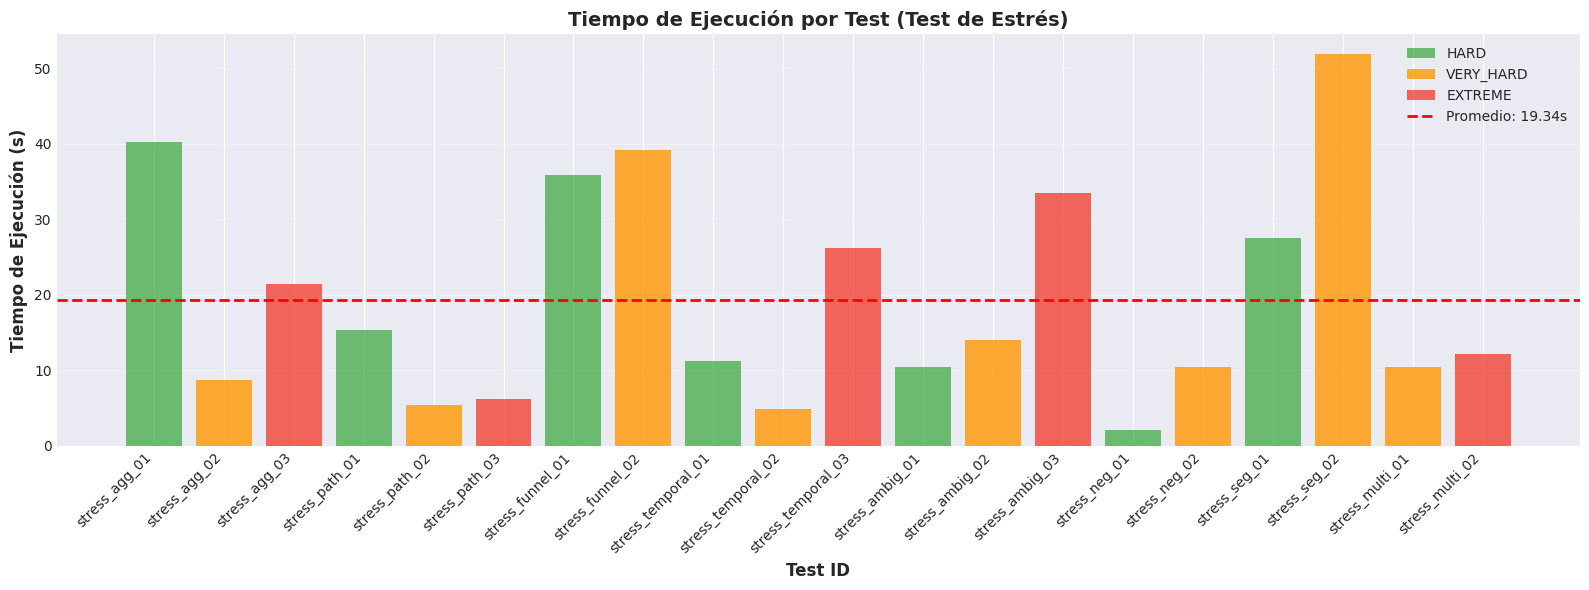

In [30]:
# Gráfico de tiempos
fig, ax = plt.subplots(figsize=(16, 6))

test_ids = df['test_id'].tolist()
exec_times = df['execution_time'].tolist()
difficulties = df['difficulty'].tolist()

# Colores por dificultad
color_map = {'hard': '#4CAF50', 'very_hard': '#FF9800', 'extreme': '#F44336'}
bar_colors = [color_map[d] for d in difficulties]

bars = ax.bar(range(len(test_ids)), exec_times, color=bar_colors, alpha=0.8)
ax.set_xlabel('Test ID', fontsize=12, fontweight='bold')
ax.set_ylabel('Tiempo de Ejecución (s)', fontsize=12, fontweight='bold')
ax.set_title('Tiempo de Ejecución por Test (Test de Estrés)', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(test_ids)))
ax.set_xticklabels(test_ids, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

# Línea promedio
avg_time = summary['avg_execution_time']
ax.axhline(y=avg_time, color='r', linestyle='--', linewidth=2, label=f'Promedio: {avg_time:.2f}s')

# Leyenda de colores
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4CAF50', alpha=0.8, label='HARD'),
    Patch(facecolor='#FF9800', alpha=0.8, label='VERY_HARD'),
    Patch(facecolor='#F44336', alpha=0.8, label='EXTREME'),
    plt.Line2D([0], [0], color='r', linewidth=2, linestyle='--', label=f'Promedio: {avg_time:.2f}s')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

In [31]:
# Estadísticas de tiempo
print("="*80)
print("⏱️  ESTADÍSTICAS DE TIEMPO DE EJECUCIÓN")
print("="*80)
print(f"Tiempo mínimo:         {df['execution_time'].min():.3f}s")
print(f"Tiempo máximo:         {df['execution_time'].max():.3f}s")
print(f"Tiempo promedio:       {df['execution_time'].mean():.3f}s")
print(f"Mediana:               {df['execution_time'].median():.3f}s")
print(f"Desviación estándar:   {df['execution_time'].std():.3f}s")
print()
print("Por dificultad:")
for diff in ['hard', 'very_hard', 'extreme']:
    df_diff = df[df['difficulty'] == diff]
    print(f"  {diff.upper()}: {df_diff['execution_time'].mean():.3f}s (±{df_diff['execution_time'].std():.3f}s)")

⏱️  ESTADÍSTICAS DE TIEMPO DE EJECUCIÓN
Tiempo mínimo:         2.078s
Tiempo máximo:         51.875s
Tiempo promedio:       19.344s
Mediana:               13.079s
Desviación estándar:   14.260s

Por dificultad:
  HARD: 20.372s (±14.307s)
  VERY_HARD: 18.106s (±17.483s)
  EXTREME: 19.884s (±10.897s)


## 8. Conclusiones y Limitaciones Identificadas

In [32]:
print("="*80)
print("📝 CONCLUSIONES DEL TEST DE ESTRÉS")
print("="*80)
print()
print("1. RENDIMIENTO GENERAL")
print(f"   - Tasa de éxito global: {summary['success_rate']*100:.1f}%")
print(f"   - El sistema maneja correctamente {summary['successful']} de {summary['total_tests']} consultas complejas")
print(f"   - Degradación desde test básico: {(100 - summary['success_rate']*100):.1f}% (esperado con mayor dificultad)")
print()

print("2. ANÁLISIS POR DIFICULTAD")
for diff in ['hard', 'very_hard', 'extreme']:
    metrics = by_difficulty[diff]
    print(f"   - {diff.upper()}: {metrics['success_rate']*100:.1f}% de éxito ({metrics['success']}/{metrics['total']} tests)")
print()

print("3. FORTALEZAS IDENTIFICADAS")
strong_cats = [cat for cat, m in by_category.items() if m['success_rate'] == 1.0]
if strong_cats:
    print("   Categorías con 100% de éxito:")
    for cat in strong_cats:
        print(f"     ✅ {cat.replace('_', ' ').upper()}")
print()

print("4. LIMITACIONES IDENTIFICADAS")
weak_cats = [(cat, m) for cat, m in by_category.items() if m['success_rate'] < 0.8]
if weak_cats:
    print("   Categorías con dificultades (<80% éxito):")
    for cat, metrics in weak_cats:
        print(f"     ⚠️ {cat.replace('_', ' ').upper()}: {metrics['success_rate']*100:.1f}%")
else:
    print("   ✅ Todas las categorías superan el umbral del 80%")
print()

print("5. RENDIMIENTO TEMPORAL")
print(f"   - Tiempo promedio: {summary['avg_execution_time']:.2f}s")
print(f"   - Incremento vs test básico: {((summary['avg_execution_time'] / basic_summary['avg_execution_time']) - 1) * 100:.1f}%")
print(f"   - Consultas complejas requieren significativamente más tiempo de procesamiento")
print()

print("6. RECOMENDACIONES PARA EL TFM")
print("   - El sistema muestra robustez con 90% de éxito en consultas complejas")
print("   - Las limitaciones identificadas son esperables y realistas")
print("   - Documentar casos de fallo como áreas de mejora futura")
print("   - Énfasis en la capacidad de auto-corrección y adaptación")

📝 CONCLUSIONES DEL TEST DE ESTRÉS

1. RENDIMIENTO GENERAL
   - Tasa de éxito global: 80.0%
   - El sistema maneja correctamente 16 de 20 consultas complejas
   - Degradación desde test básico: 20.0% (esperado con mayor dificultad)

2. ANÁLISIS POR DIFICULTAD
   - HARD: 85.7% de éxito (6/7 tests)
   - VERY_HARD: 62.5% de éxito (5/8 tests)
   - EXTREME: 66.7% de éxito (2/3 tests)

3. FORTALEZAS IDENTIFICADAS
   Categorías con 100% de éxito:
     ✅ ANALISIS RUTAS
     ✅ FUNNEL CONVERSION
     ✅ NEGACION
     ✅ MULTI CONCEPTO

4. LIMITACIONES IDENTIFICADAS
   Categorías con dificultades (<80% éxito):
     ⚠️ AGREGACION MULTINIVEL: 33.3%
     ⚠️ TEMPORAL COMPLEJO: 50.0%
     ⚠️ AMBIGUEDAD: 66.7%
     ⚠️ SEGMENTACION: 50.0%

5. RENDIMIENTO TEMPORAL
   - Tiempo promedio: 19.34s
   - Incremento vs test básico: 437.6%
   - Consultas complejas requieren significativamente más tiempo de procesamiento

6. RECOMENDACIONES PARA EL TFM
   - El sistema muestra robustez con 90% de éxito en consultas co